In [1]:
import numpy as np

In [2]:
import libertem.api as lt

In [3]:
import matplotlib.pyplot as plt

In [4]:
from libertem.udf import UDF

In [5]:
%matplotlib widget

In [6]:
class PositionAverageSig(UDF):
        
    def get_result_buffers(self):
        return {
            'sumSig': self.buffer(kind='sig', dtype='float32'),
            'num_frames': self.buffer(kind='single', dtype='int64'),
            'meanSig': self.buffer(kind='sig', dtype='float32', use='result_only'),
        }

    def process_frame(self, frame):
        self.results.sumSig[:] += frame
        self.results.num_frames[:] += 1

    def merge(self, dest, src):
        dest.sumSig[:] += src.sumSig
        dest.num_frames[:] += src.num_frames

    def get_results(self):
        return {
            'meanSig': self.results.sumSig / self.results.num_frames[:],
        }

In [7]:
class VirtualFieldImaging(UDF):
    """
    """

    def __init__(self, center = None, radius = 5, *args, **kwargs):
        super().__init__(*args, center = center, radius = radius, **kwargs)

    def get_result_buffers(self):
  
        return {
            "vfi_frame": self.buffer(kind = 'nav', 
                                     dtype = 'float32'
                                   )
        }

    def process_frame(self, frame):
        sx, sy = self.meta.dataset_shape[2], self.meta.dataset_shape[3]
        if self.params.center == None:
            r0, c0  = (sx//2, sy//2)
        else:
            r0, c0 = self.params.center

        mask = np.zeros((sx, sy))
        rr, cc = np.mgrid[0:sx, 0:sy]
        mask[(rr - r0)**2 + (cc - c0)**2 <= self.params.radius**2] = 1

        sum_intensity = np.sum(frame * mask)
        self.results.vfi_frame[:] = sum_intensity


In [8]:
import os

In [9]:
work_dir = '/Users/nihy/Desktop/Working Data/CrSBr/ds2'

In [10]:
file_path = '/Users/nihy/Desktop/Working Data/CrSBr/ds2/descan_corrected.npy'

# Load Data

In [11]:
ctx = lt.Context()

In [12]:
data = ctx.load("NPY", file_path)
data

<NPYDataSet of uint32 shape=(52, 1000, 128, 128)>

In [13]:
res_panbd = ctx.run_udf(dataset=data, udf=PositionAverageSig(), progress = True)

Partitions 0/15, Frames:   0%|          | 0/52000 [00:00<?, ?it/s]

In [14]:
res_pixelsum_2 = ctx.run_udf(dataset=data, udf=VirtualFieldImaging(radius = 20), progress=True)


Partitions 0/15, Frames:   0%|          | 0/52000 [00:00<?, ?it/s]

In [15]:
res_panbd['meanSig'].data

array([[123.78440385, 123.94253846, 122.56613462, ...,   0.        ,
          0.        ,   0.        ],
       [147.18911538, 146.83932692, 147.49325   , ...,   0.        ,
          0.        ,   0.        ],
       [167.25028846, 167.57338462, 170.79021154, ...,   0.        ,
          0.        ,   0.        ],
       ...,
       [237.22098077, 243.67865385, 258.79371154, ...,   0.        ,
          0.        ,   0.        ],
       [209.73401923, 212.22613462, 220.21690385, ...,   0.        ,
          0.        ,   0.        ],
       [173.33234615, 177.27196154, 179.09155769, ...,   0.        ,
          0.        ,   0.        ]], shape=(128, 128))

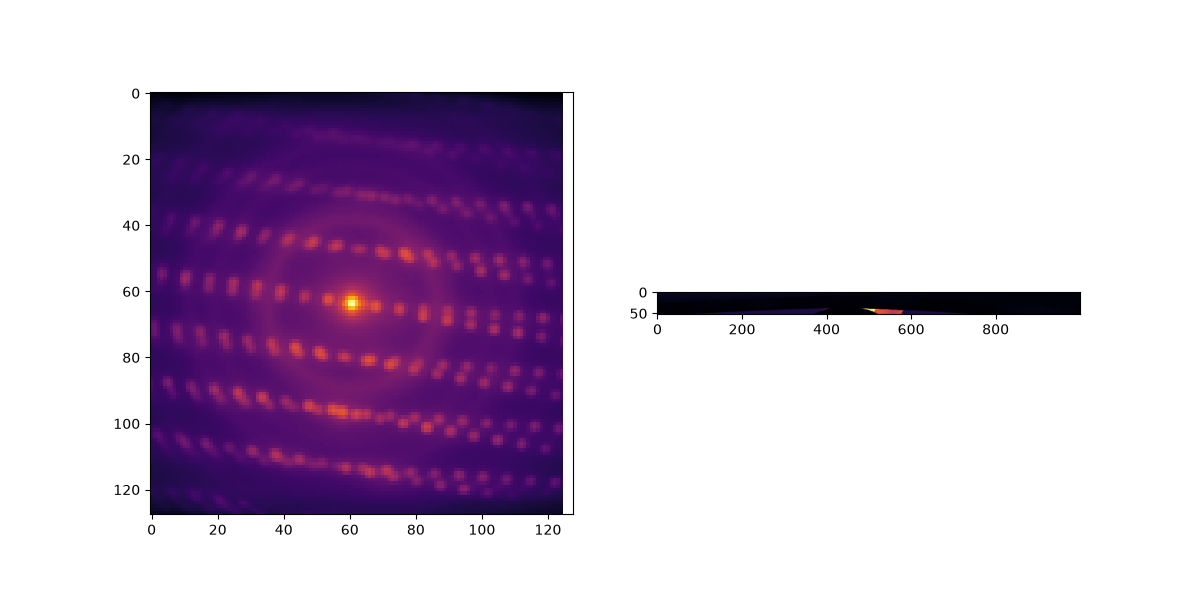

In [16]:
_, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].imshow(res_panbd['meanSig'].data, cmap = 'inferno', norm = 'log')
axs[1].imshow(res_pixelsum_2['vfi_frame'].data, cmap = 'inferno')

# Calculate Cepstrum

In [19]:
class CalculateCepstrum(UDF):
    def get_backends(self):
        return self.BACKEND_ALL

    def __init__(self, window = True, pad = True, pad_shape = (1024, 1024), output_shape = (128, 128), *args, **kwargs):
        """
        Cepstrum transform
        parameters
        window : Bool
            If true, a hann window will be applied

        pad : Bool
            If True, the input will be padded

        pad_shape : int
            If pad = True, pad_width specifies the padded frame size

        output_shape : int
            Specify the output shape
        ----------
        """
        super().__init__(*args, window = window, pad = pad, pad_shape = pad_shape, output_shape = output_shape)

    def get_result_buffers(self):
        return {
            "cepstrum": self.buffer(kind = 'nav', dtype = self.xp.float32, extra_shape = self.params.output_shape, where = 'device')
        }

    def process_frame(self, frame):
        output_shape = self.params.output_shape
        sx, sy = self.meta.dataset_shape[2], self.meta.dataset_shape[3]

        frame[frame<1] = 1

        if self.params.window: # Create Windowing
            xx, yy = self.xp.mgrid[0:sx,0:sy]
            w = (1/2-1/2*self.xp.cos(2*self.xp.pi*xx/sx))*(1/2-1/2*self.xp.cos(2*self.xp.pi*yy/sy))


        if self.params.pad and self.params.pad_shape:
            pad_width = ((self.params.pad_shape[0] - sx)//2, (self.params.pad_shape[1] - sy)//2)

        else:
            pad_width = ((0, 0), (0, 0))


        dp_log = self.xp.log(frame)
        dp_pad = self.xp.pad(dp_log*w, pad_width, mode='constant', constant_values=0)

        ceps = self.xp.abs(self.xp.fft.fftshift(self.xp.fft.fft2(self.xp.fft.ifftshift(dp_pad))))
        ceps = ceps[ceps.shape[0]//2 - output_shape[0]//2 : ceps.shape[0]//2 + output_shape[0]//2, ceps.shape[1]//2 - output_shape[1]//2 : ceps.shape[1]//2 + output_shape[1]//2]


        #t = self.xp.percentile(ceps,99.99)
        #ceps[ceps>t] = t
        #ceps = (ceps - ceps.min())/(ceps.max() - ceps.min())*32767


        self.results.cepstrum[:] = ceps.astype("float32")


In [20]:
cepstrum = ctx.run_udf(dataset=data, udf=CalculateCepstrum(window = True, pad = True, pad_shape = (256,256), output_shape = (128, 128)), backends=('numpy',), progress=True)

Partitions 0/15, Frames:   0%|          | 0/52000 [00:00<?, ?it/s]

In [21]:
np.save(os.path.join(work_dir, 'cepstrum.npy'), cepstrum['cepstrum'].data)

In [22]:
ctx.close()

# Analyze Cepstrum peak positions using CoM

In [23]:
from scipy.ndimage import gaussian_filter as gaussian

In [24]:
ctx = lt.Context()

In [86]:
data = np.load(file_path, mmap_mode ='r')

In [25]:
cepstrum = ctx.load("npy", os.path.join(work_dir, 'cepstrum.npy'))

In [26]:
PosAvgCeps = ctx.run_udf(dataset=cepstrum, udf=PositionAverageSig(), progress = True)

Partitions 0/15, Frames:   0%|          | 0/52000 [00:00<?, ?it/s]

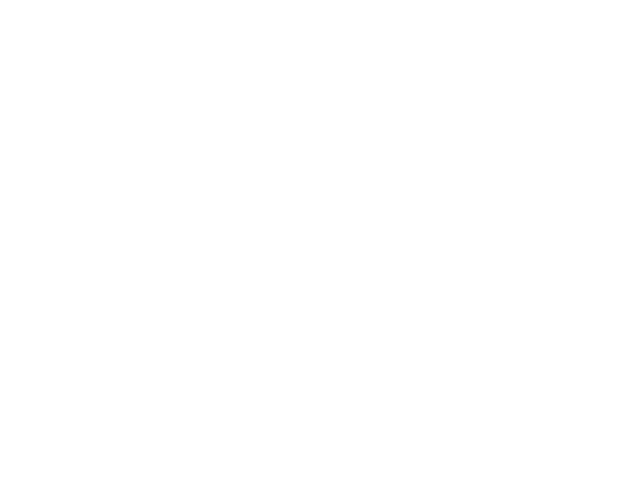

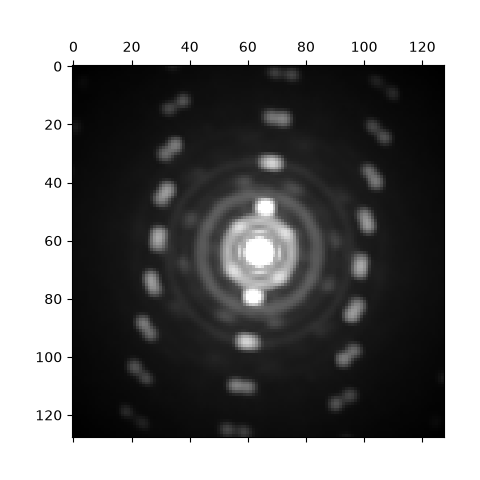

In [27]:
plt.figure()
plt.matshow(PosAvgCeps['meanSig'].data, cmap='gray', vmax =5e2, norm = 'log')

In [28]:
class FindSigCenterCoM(UDF):
    def __init__(self, c_row, c_column, rin, rout = None, *args, **kwargs):
        """
        Find 4D-STEM Disk Deflection using Center-of-mass method
        parameters
        ----------
        """
        if rout is None:
            rout = 1000

        super().__init__(*args,c_row = c_row, c_column = c_column, rin = rin, rout = rout)

    def get_result_buffers(self):
        return {
            "center": self.buffer(kind = 'nav', dtype = self.xp.float64, extra_shape = (2,))
        }

    def process_frame(self, frame):
        cr, cc, rin, rout = self.params.c_row, self.params.c_column, self.params.rin, self.params.rout
        sr, sc = self.meta.dataset_shape[2], self.meta.dataset_shape[3]

        srr, scc = np.mgrid[0:sr, 0:sc]
        mask = ((srr - cr)**2 + (scc - cc)**2 < rout**2)&((srr - cr)**2 + (scc - cc)**2 > rin**2)

        com = (self.xp.sum(frame*mask*srr, axis=(0,1)) / self.xp.sum(frame*mask), self.xp.sum(frame*mask*scc, axis=(0,1)) / self.xp.sum(frame*mask))

        self.results.center[:] =  com

In [29]:
com_a_ceps = ctx.run_udf(dataset=cepstrum, udf=FindSigCenterCoM(c_row = 33, c_column = 68, rin = 0, rout = 5), progress=True)

Partitions 0/15, Frames:   0%|          | 0/52000 [00:00<?, ?it/s]

In [30]:
com_c_ceps = ctx.run_udf(dataset=cepstrum, udf=FindSigCenterCoM(c_row = 69, c_column = 99, rin = 0, rout = 8), progress=True)

Partitions 0/15, Frames:   0%|          | 0/52000 [00:00<?, ?it/s]

In [31]:
com_a_ceps = com_a_ceps['center'].data
com_c_ceps = com_c_ceps['center'].data

In [32]:
com_a_ceps.min(), com_a_ceps.max()

(np.float64(31.763487596373015), np.float64(69.71265130410623))

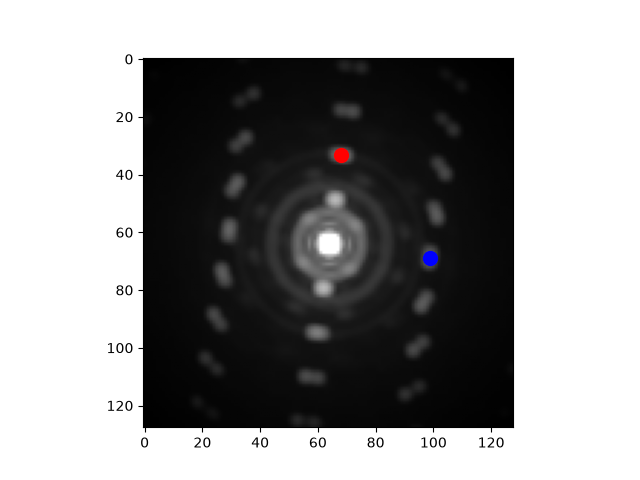

In [33]:
plt.figure()
plt.imshow(PosAvgCeps['meanSig'].data, cmap='gray', vmax =3e3, norm = 'log')
plt.scatter(com_a_ceps[...,1].mean(), com_a_ceps[...,0].mean(), s = 100, c = 'r')
plt.scatter(com_c_ceps[...,1].mean(), com_c_ceps[...,0].mean(), s = 100, c = 'b')

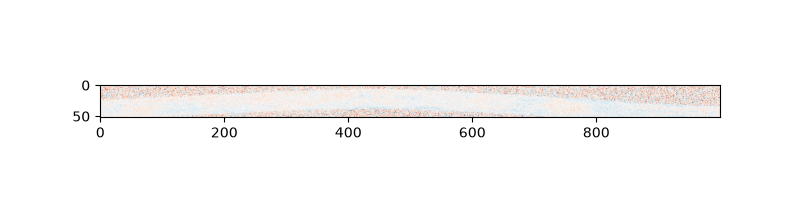

In [34]:
plt.figure(figsize = (8,2))
plt.imshow(np.sqrt((com_a_ceps[...,1] - 64)**2 + (com_a_ceps[...,0] - 64)**2), cmap = 'RdBu_r')

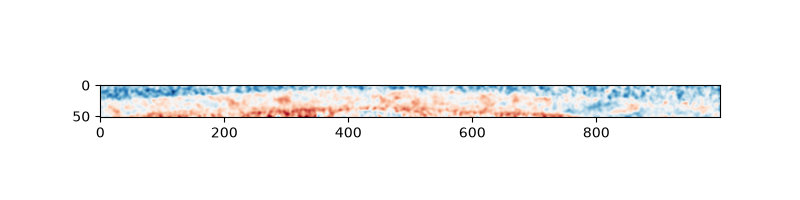

In [35]:
plt.figure(figsize = (8,2))
plt.imshow(gaussian(np.sqrt((com_c_ceps[...,1] - 64)**2 + (com_c_ceps[...,0] - 64)**2), 2), cmap = 'RdBu_r')

In [36]:
sample_mask = gaussian(np.sqrt((com_a_ceps[...,1] - 64)**2 + (com_a_ceps[...,0] - 64)**2), 5)>15

In [37]:
ref_a = com_a_ceps[11:38, 300:500].mean((0,1)) - np.array([64, 64])
ref_c = com_c_ceps[11:38, 300:500].mean((0,1)) - np.array([64, 64])
ref_a, ref_c

(array([-30.76589855,   4.53807915]), array([ 5.18144532, 34.76054311]))

In [38]:
R0 = np.stack([ref_a, ref_c], axis = 1)
R0

array([[-30.76589855,   5.18144532],
       [  4.53807915,  34.76054311]])

In [39]:
a_vecs = com_a_ceps - np.array([64,64])
c_vecs = com_c_ceps - np.array([64,64])

In [40]:
R = np.stack([a_vecs, c_vecs], axis = -1)
R.shape

(52, 1000, 2, 2)

In [41]:
def fit_T(R, R0, weights=None):
    """
    R  : (..., 2, N) measured peak vectors, leading dims = scan grid
    R0 : (2, N) reference vectors
    returns T : (..., 2, 2)
    """
    W = np.eye(R0.shape[1]) if weights is None else np.diag(weights)
    A = R0 @ W @ R0.T                      # (2,2), same for all probes
    return np.einsum('...in,nm,mj->...ij', R, W @ R0.T, np.linalg.inv(A))

def decompose(T, polar=True):
    if polar:
        U_, s, Vt = np.linalg.svd(T)
        Q = U_ @ Vt
        U = (Vt.transpose(*range(Vt.ndim-2), -1, -2) * s[..., None, :]) @ Vt
        eps = U - np.eye(2)
        theta = np.arctan2(Q[..., 1, 0], Q[..., 0, 0])
    else:
        e = T - np.eye(2)
        eps = 0.5 * (e + e.transpose(*range(e.ndim-2), -1, -2))
        theta = 0.5 * (e[..., 1, 0] - e[..., 0, 1])
    return eps[..., 0, 0], eps[..., 1, 1], eps[..., 0, 1], theta

def residual(T, R, R0):
    return np.linalg.norm(R - T @ R0, axis=(-2, -1)) / np.sqrt(R0.shape[1])

In [42]:
T = fit_T(R, R0)
T.shape

(52, 1000, 2, 2)

In [43]:
eps_matrices = decompose(T, polar=True)

Text(0.5, 1.0, '$Rotation$')

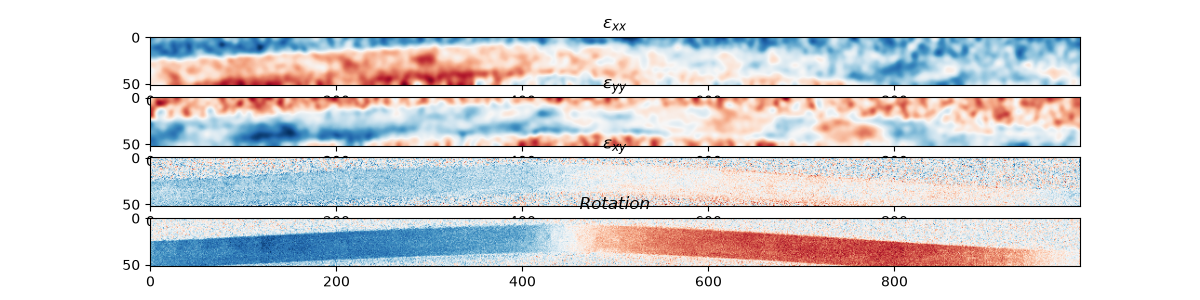

In [116]:
_, axs = plt.subplots(4, 1, figsize=(12, 3))
axs[0].imshow(gaussian(eps_matrices[1],3), cmap='RdBu_r')
axs[0].set_title(r'$\epsilon_{xx}$')
axs[1].imshow(gaussian(eps_matrices[0],3), cmap='RdBu_r')
axs[1].set_title(r'$\epsilon_{yy}$')

axs[2].imshow(eps_matrices[2], cmap='RdBu_r')
axs[2].set_title(r'$\epsilon_{xy}$')
axs[3].imshow(eps_matrices[3], cmap='RdBu_r')
axs[3].set_title(r'$Rotation$')


In [62]:
roi_left = np.zeros(cepstrum.shape[0:2])
roi_right = np.zeros(cepstrum.shape[0:2])

In [63]:
roi_left[20:30, 200:210] = 1
roi_right[20:30, 600:610] = 1

In [64]:
ceps_left = ctx.run_udf(dataset = cepstrum, udf = PositionAverageSig(), roi = roi_left, progress = True)['meanSig'].data 

Partitions 0/4, Frames:   0%|          | 0/100 [00:00<?, ?it/s]

In [65]:
ceps_right = ctx.run_udf(dataset = cepstrum, udf = PositionAverageSig(), roi = roi_right, progress = True)['meanSig'].data 

Partitions 0/4, Frames:   0%|          | 0/100 [00:00<?, ?it/s]

In [66]:
from scipy.ndimage import rotate

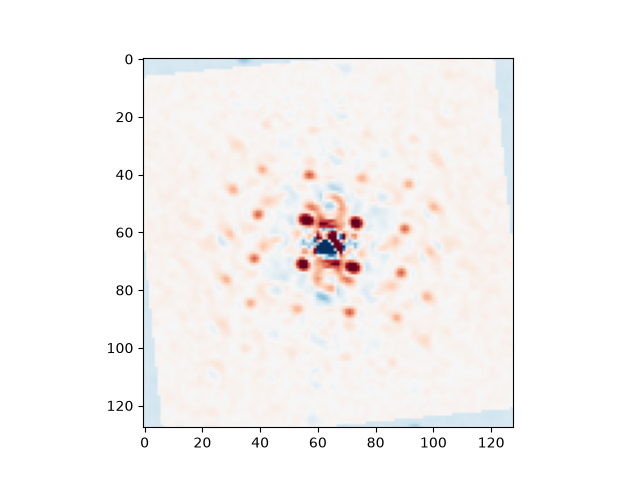

In [84]:
plt.figure()
plt.imshow(rotate(ceps_left,5.7,reshape = False) - ceps_right, cmap = 'RdBu_r', vmin = -200, vmax = 200)

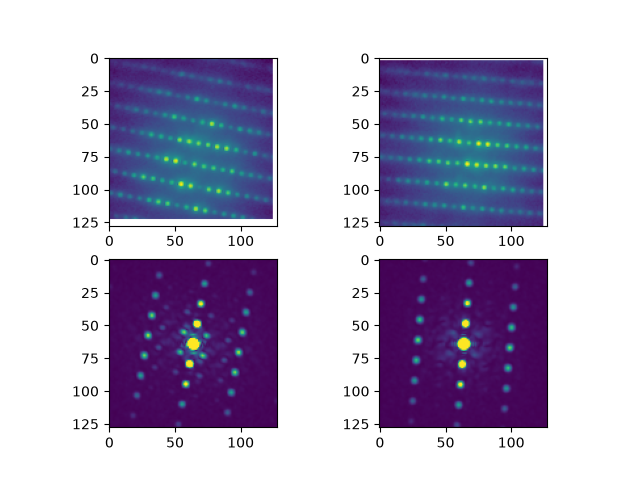

In [90]:
_, axs = plt.subplots(2, 2)
axs[0,0].imshow(data[20:30, 200:210].mean((0,1)), norm = 'log')
axs[0,1].imshow(data[20:30, 600:610].mean((0,1)), norm = 'log')
axs[1,0].imshow(ceps_left, vmax = 600)
axs[1,1].imshow(ceps_right, vmax = 600)

In [94]:
a_vecs[20:30, 200:210].mean((0,1)), c_vecs[20:30, 200:210].mean((0,1))

(array([-30.69079923,   5.27574554]), array([ 5.70784125, 34.73115707]))

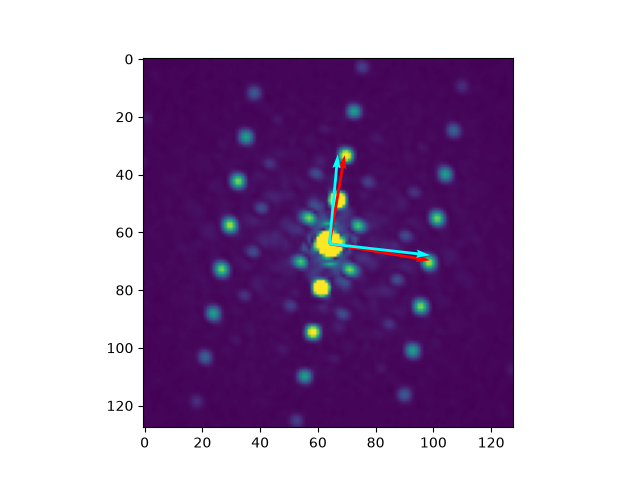

In [111]:
plt.figure()
plt.imshow(ceps_left, vmax = 600)
plt.quiver(64, 64, a_vecs[20:30, 200:210].mean((0,1))[1], -a_vecs[20:30, 200:210].mean((0,1))[0], scale_units  = 'xy', color = 'r', scale = 1)
plt.quiver(64, 64, c_vecs[20:30, 200:210].mean((0,1))[1], -c_vecs[20:30, 200:210].mean((0,1))[0], scale_units  = 'xy', color = 'r', scale = 1)

plt.quiver(64, 64, a_vecs[20:30, 600:610].mean((0,1))[1], -a_vecs[20:30, 600:610].mean((0,1))[0], scale_units  = 'xy', color = 'cyan', scale = 1)
plt.quiver(64, 64, c_vecs[20:30, 600:610].mean((0,1))[1], -c_vecs[20:30, 600:610].mean((0,1))[0], scale_units  = 'xy', color = 'cyan', scale = 1)

In [113]:
angle_rad = np.arctan2(a_vecs[20:30, 200:210].mean((0,1))[1], a_vecs[20:30, 200:210].mean((0,1))[0]) - np.arctan2(c_vecs[20:30, 200:210].mean((0,1))[1], c_vecs[20:30, 200:210].mean((0,1))[0])
angle_rad

np.float64(1.563447697668736)

In [117]:
angle_rad = np.arctan2(a_vecs[20:30, 600:610].mean((0,1))[1], a_vecs[20:30, 600:610].mean((0,1))[0]) - np.arctan2(c_vecs[20:30, 600:610].mean((0,1))[1], c_vecs[20:30, 600:610].mean((0,1))[0])
angle_rad

np.float64(1.5897441730729043)